# Conditioning switching — FLUX.2 Klein base 9B

## Setup

Install from the repository root: `python -m pip install -e ".[flux,notebook]"`.
Accept the [model’s access terms](https://huggingface.co/black-forest-labs/FLUX.2-klein-base-9B) and run `hf auth login` before loading.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from switching import Schedule
from switching.flux9b import load_pipeline, generate, SELECTIVE_THRESHOLDS

# Works when Jupyter starts in either the repository root or examples/.
EXAMPLES = (Path("examples") if Path("examples/assets").exists() else Path(".")).resolve()
DEVICE = "cuda:0"
pipe = load_pipeline(device=DEVICE, cpu_offload=True)

## Input

The editing instruction describes the edit; the caption describes the desired image.

In [2]:
image = Image.open(EXAMPLES / "assets/imgedit_fox.png").convert("RGB")
instruction = 'Replace the blue bird in the image with a red fox.'
caption = "A close-up, square-framed wildlife photograph of a vibrant red fox sitting amidst tall, lush green grass. The fox's body is angled away from the camera, but its head is turned to the right, looking back over its shoulder with its mouth slightly open. Bright, natural daylight illuminates the scene, highlighting the sharp details and rich texture of the fox's red-orange fur against the soft-focus, blurred green background. The camera is at eye-level, capturing a candid moment with a shallow depth of field."
improved_instruction = "Replace the blue bird perched on the green plant stem with a realistic red fox, maintaining the original background."
SEED = 1337
STEPS = 50
START, END = 10, 20
SAMPLING = "diffusers"
GUIDANCE_SCALE = 4.0

In [3]:
outputs, diagnostics = {}, {}

def run(mode, start=START, end=END):
    if mode == "pure_editing":
        start = end = 0
    key = (mode, start, end)
    if key not in outputs:
        info = {}
        outputs[key] = generate(
            pipe, image, instruction, caption=caption,
            improved_instruction=improved_instruction,
            schedule=Schedule(mode, steps=STEPS, start=start, end=end),
            seed=SEED, guidance_scale=GUIDANCE_SCALE, sampling=SAMPLING,
            diagnostics=info,
        )
        diagnostics[key] = info
    return outputs[key]

## Staying in T2I vs. switching back to E

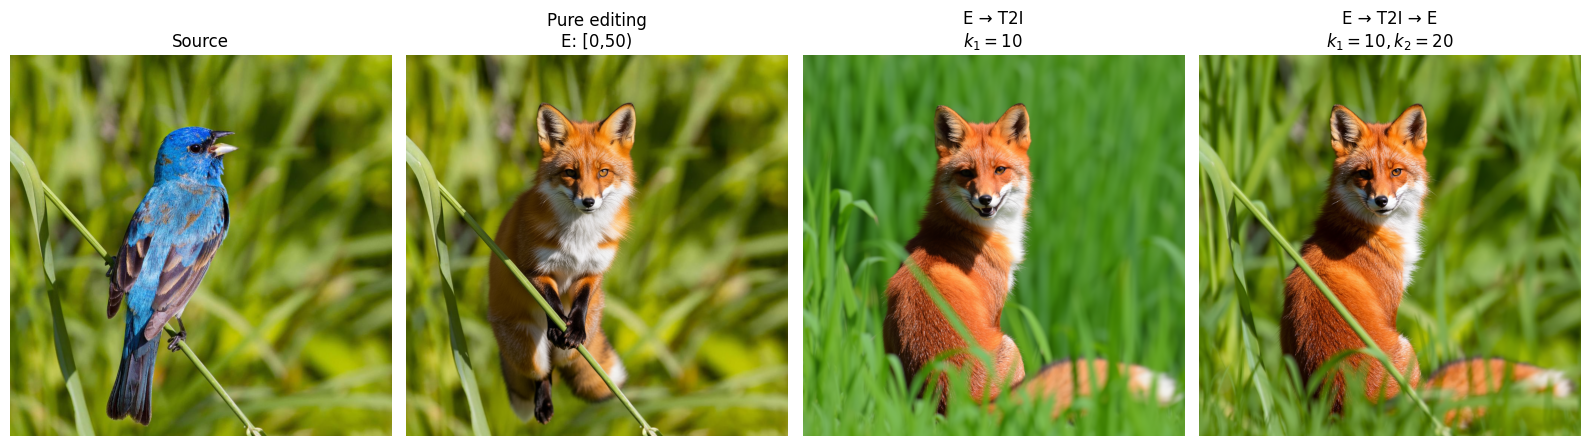

In [4]:
reference = [
    (f"Pure editing\nE: [0,{STEPS})", run("pure_editing")),
    ("E → T2I\n$k_1=10$", run("editing_t2i_editing", 10, 50)),
    ("E → T2I → E\n$k_1=10, k_2=20$", run("editing_t2i_editing", 10, 20)),
]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (label, result) in zip(axes, [("Source", image)] + reference):
    ax.imshow(result)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

## All modes

Rows show image conditioning; columns show text conditioning before, during, and after `[k1,k2)`.
`x`: source image; `p`: editing instruction; `c`: target caption; `p*`: improved editing instruction; `∅`: no source.

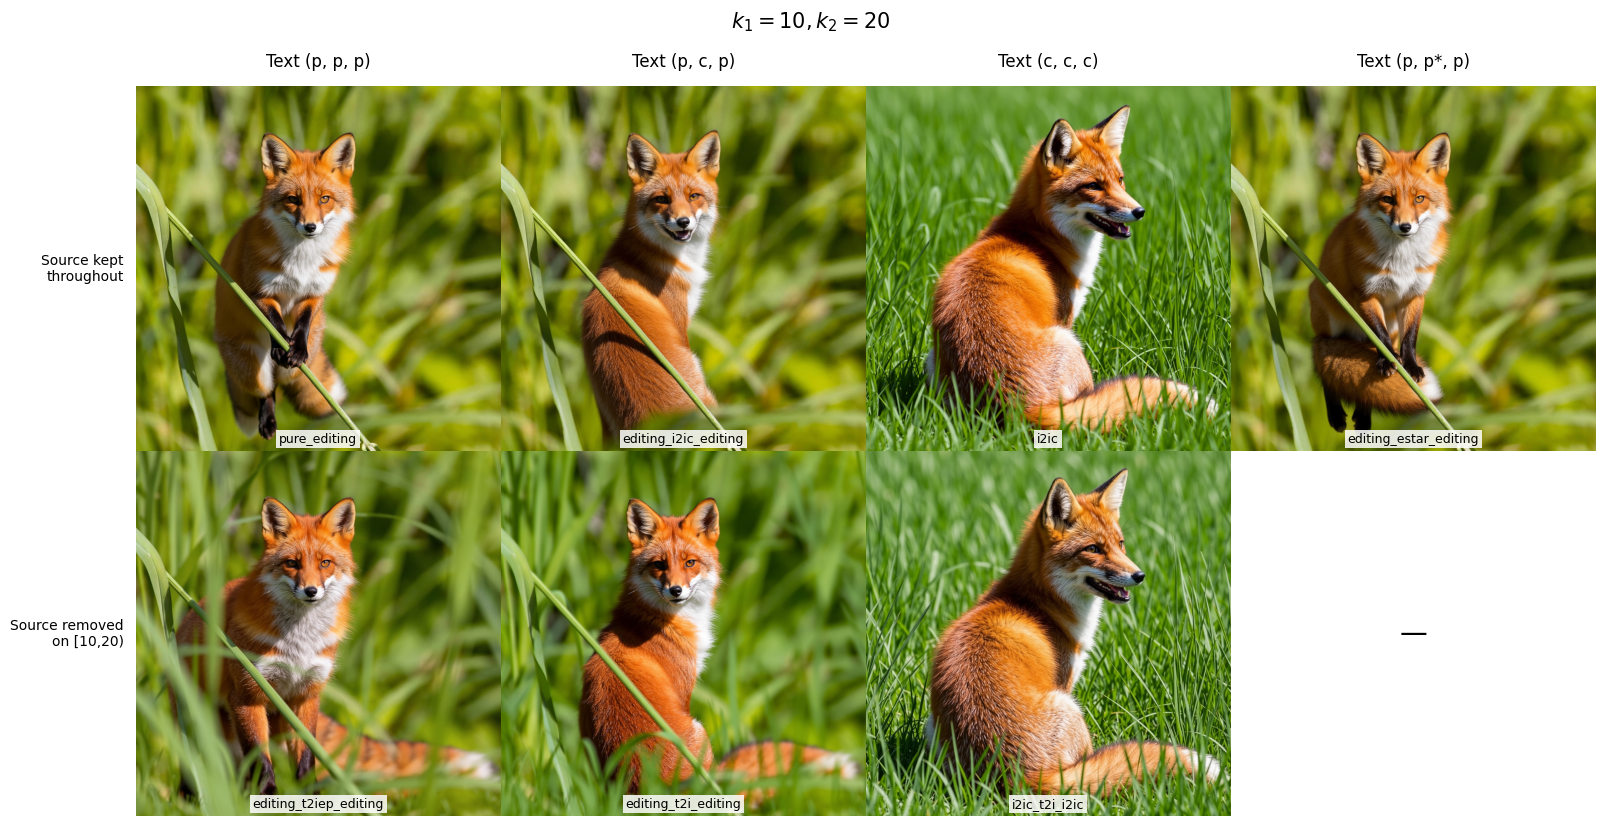

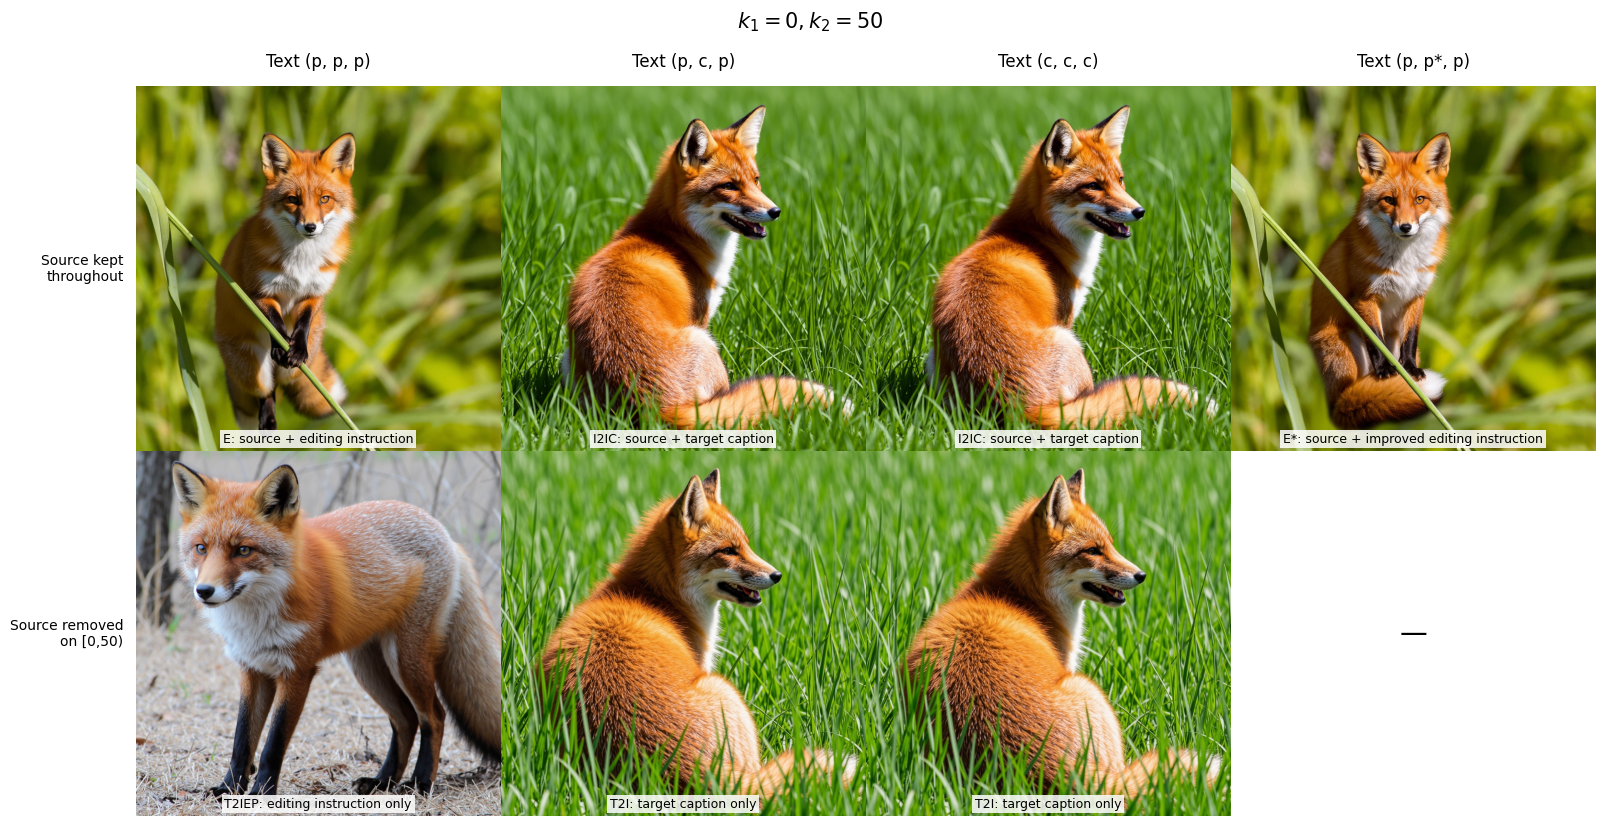

In [5]:
text_schedules = ["(p, p, p)", "(p, c, p)", "(c, c, c)", "(p, p*, p)"]
mode_grid = [
    ["pure_editing", "editing_i2ic_editing", "editing_i2ic_editing", "editing_estar_editing"],
    ["editing_t2iep_editing", "editing_t2i_editing", "i2ic_t2i_i2ic", None],
]

full_labels = [
    ["E: source + editing instruction", "I2IC: source + target caption",
     "I2IC: source + target caption", "E*: source + improved editing instruction"],
    ["T2IEP: editing instruction only", "T2I: target caption only", "T2I: target caption only", None],
]

for k1, k2 in [(10, 20), (0, 50)]:
    fig = plt.figure(figsize=(16, 8.3))
    left, bottom, tile = 1.25, 0.15, 3.65
    for row, image_schedule in enumerate([
        "Source kept\nthroughout",
        f"Source removed\non [{k1},{k2})",
    ]):
        for col, mode in enumerate(mode_grid[row]):
            ax = fig.add_axes([(left + col * tile) / 16,
                               (bottom + (1 - row) * tile) / 8.3,
                               tile / 16, tile / 8.3])
            ax.axis("off")
            if mode is None:
                ax.text(0.5, 0.5, "—", ha="center", va="center", fontsize=20)
                continue
            if (row, col) == (0, 2):
                result = run("editing_i2ic_editing", 0, STEPS)
                label = "i2ic"
            else:
                result = run(mode, k1, k2)
                label = mode
            if (k1, k2) == (0, STEPS):
                label = full_labels[row][col]
            ax.imshow(result)
            ax.text(0.5, 0.015, label, transform=ax.transAxes,
                    ha="center", va="bottom", fontsize=9,
                    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 2})
        fig.text((left - 0.12) / 16, (bottom + (1.5 - row) * tile) / 8.3,
                 image_schedule, ha="right", va="center", fontsize=10)
    for col, text_schedule in enumerate(text_schedules):
        fig.text((left + (col + 0.5) * tile) / 16, 7.65 / 8.3,
                 f"Text {text_schedule}", ha="center", fontsize=12)
    fig.suptitle(f"$k_1={k1}, k_2={k2}$", y=0.99, fontsize=15)
    plt.show()

## Selective switching

At step 9, CV measures spatial variation in source attention; π is its 75th percentile.
High CV indicates uneven source reliance; high π indicates stronger source reliance.
If either exceeds its threshold, keep pure editing; otherwise use T2I on `[10,16)`.
The CV map shows local 3 × 3 variation; the decision uses full-map CV.

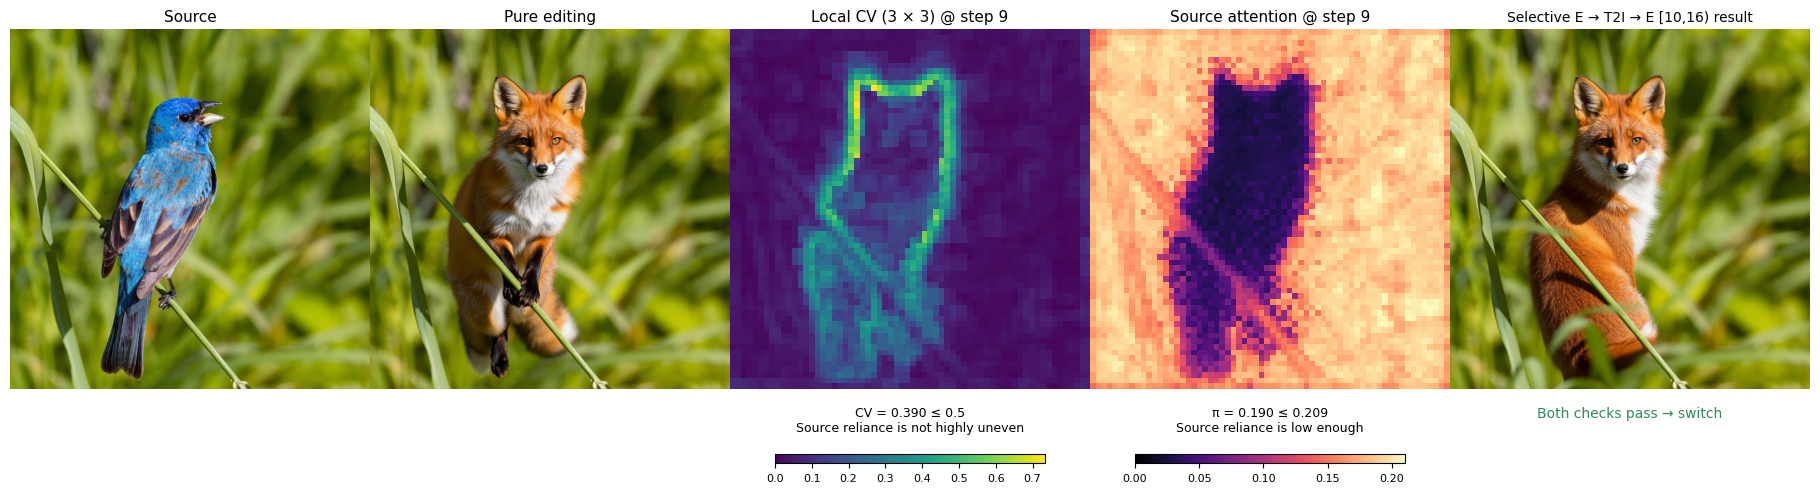

In [6]:
mode = "editing_t2i_editing_selective"
k1, k2 = 10, 16
result = run(mode, k1, k2)
info = diagnostics[(mode, k1, k2)]

fig = plt.figure(figsize=(18, 5.2))
axes = [fig.add_axes([col / 5, 1.05 / 5.2, 1 / 5, 3.6 / 5.2]) for col in range(5)]
axes[0].imshow(image)
axes[0].set_title("Source", fontsize=11)
for col, values, title, cmap, name, value, threshold, meaning in [
    (2, info["local_cv"], "Local CV (3 × 3)", "viridis", "CV", info["cv"], SELECTIVE_THRESHOLDS[0],
     "Source reliance is not highly uneven" if info["cv"] <= SELECTIVE_THRESHOLDS[0] else "Source reliance is highly uneven"),
    (3, info["attention"], "Source attention", "magma", "π", info["pi"], SELECTIVE_THRESHOLDS[1],
     "Source reliance is low enough" if info["pi"] <= SELECTIVE_THRESHOLDS[1] else "Source reliance is relatively high"),
]:
    ax = axes[col]
    plot = ax.imshow(values, cmap=cmap, vmin=0, interpolation="nearest")
    ax.set_title(f"{title} @ step {info['step']}", fontsize=11)
    comparison = "≤" if value <= threshold else ">"
    ax.text(0.5, -0.045, f"{name} = {value:.3f} {comparison} {threshold:g}\n{meaning}",
            transform=ax.transAxes, ha="center", va="top", fontsize=9)
    bar = fig.add_axes([col / 5 + 0.025, 0.06, 0.15, 0.018])
    fig.colorbar(plot, cax=bar, orientation="horizontal")
    bar.tick_params(labelsize=8)

axes[4].imshow(result)
axes[4].set_title(f"Selective E → T2I → E [{k1},{k2}) result", fontsize=10)
decision = "Both checks pass → switch" if info["switched"] else "Threshold exceeded → keep pure editing"
axes[4].text(0.5, -0.045, decision, transform=axes[4].transAxes,
             ha="center", va="top", fontsize=10,
             color="seagreen" if info["switched"] else "firebrick")
axes[1].imshow(run("pure_editing"))
axes[1].set_title("Pure editing", fontsize=11)
for ax in axes:
    ax.axis("off")
plt.show()

## Save images

In [7]:
output_dir = EXAMPLES.parent / "outputs" / "9b-notebook"
output_dir.mkdir(parents=True, exist_ok=True)
for (mode, k1, k2), result in outputs.items():
    result.save(output_dir / f"{mode}_{k1}_{k2}.png")